# Data Labelling (University of Bonn - Single Channel)

## Import Python's Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Load Dataset

In [2]:
# train dataset loaded
healthy_array = np.load("../../data/ukb_processed/normal/healthy_signal.npy")
interictal_array = np.load("../../data/ukb_processed/normal/interictal_signal.npy")
ictal_array = np.load("../../data/ukb_processed/normal/ictal_signal.npy")
augmented_ictal_array = np.load("../../data/ukb_processed/normal/augmented_ictal_signal.npy")

healthy = list(healthy_array)
interictal = list(interictal_array)
ictal = list(ictal_array)
augmented_ictal = list(augmented_ictal_array)

print(healthy)  # menampilkan isi array pertama
print(interictal)  # menampilkan isi array pertama
print(ictal)  # menampilkan isi array pertama
print(augmented_ictal)  # menampilkan isi array pertama

print(len(healthy))
print(len(interictal))
print(len(ictal))
print(len(augmented_ictal))

[array([ 12.,  22.,  35., ..., -11.,   8.,  77.]), array([ -56.,  -50.,  -64., ..., -173., -162.,  -82.]), array([-37., -22., -17., ...,   3.,   4.,  82.]), array([-31., -43., -39., ...,  -6.,  10.,  33.]), array([ 14.,  26.,  32., ..., -32.,  -6., -17.]), array([-87., -89., -73., ...,  18.,   7.,   7.]), array([ -2.,  20.,  42., ..., -18.,  -6., -37.]), array([-31., -16.,  10., ...,   1.,   1.,   0.]), array([  8.,  17.,  29., ..., -40., -36.,   7.]), array([-41., -38., -31., ...,   1., -13.,  -1.]), array([ 14.,  25.,  31., ..., -26., -28.,  21.]), array([-64., -72., -52., ..., -36., -58.,  20.]), array([ 10.,  -6., -14., ...,  15.,   6., -46.]), array([31., 25., 17., ..., 23., 28., 65.]), array([ 30.,  19.,  -3., ..., -11., -13.,  -6.]), array([ 34.,  34.,  31., ...,  -7., -20.,  91.]), array([-62., -55., -44., ..., -20., -22.,  35.]), array([-18.,  -9.,   9., ..., 109.,  67.,  50.]), array([  0.,   2.,  -1., ...,  23.,  21., -16.]), array([-20.,  -3.,   2., ..., -28., -10.,   3.]),

## Signals Visualization

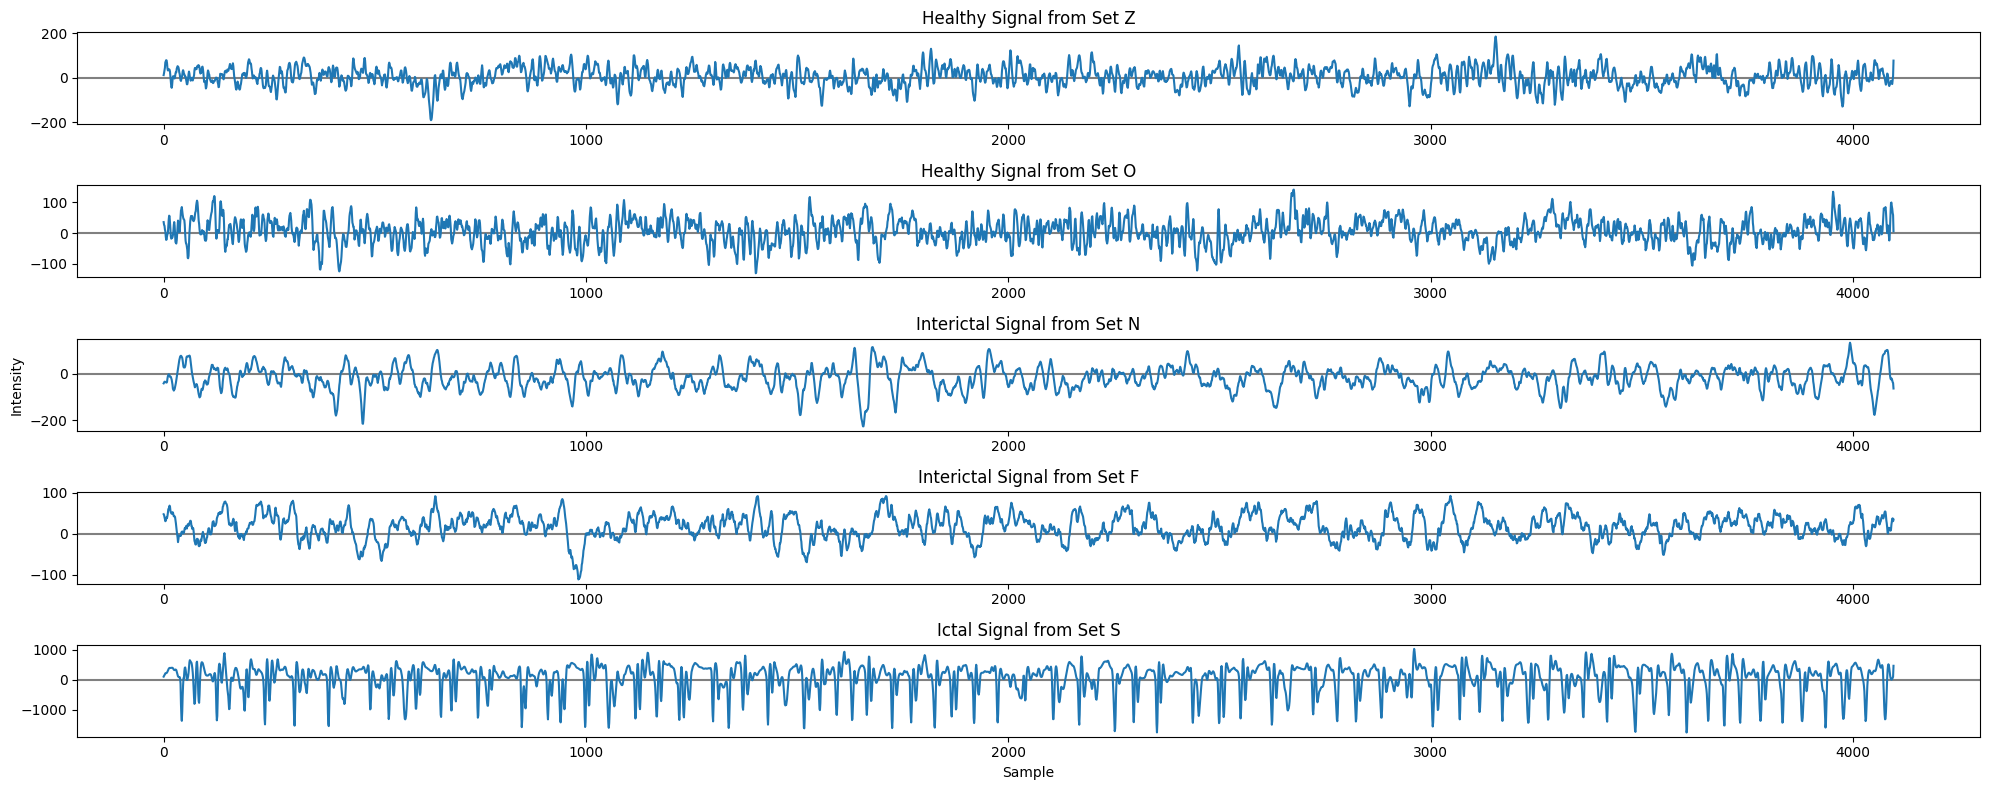

In [3]:
signal_1 = healthy[0]           # from set Z
signal_2 = healthy[80]          # from set O
signal_3 = interictal[0]        # from set N
signal_4 = interictal[80]       # from set F
signal_5 = ictal[0]             # from set S

fig, axes = plt.subplots(5, 1, figsize=(20, 8))
axes[0].axhline(0, color='grey')
axes[0].plot(signal_1)
axes[0].set_title('Healthy Signal from Set Z')

axes[1].axhline(0, color='grey')
axes[1].plot(signal_2)
axes[1].set_title('Healthy Signal from Set Ο')

axes[2].axhline(0, color='grey')
axes[2].plot(signal_3)
axes[2].set_ylabel('Intensity')
axes[2].set_title('Interictal Signal from Set N')

axes[3].axhline(0, color='grey')
axes[3].plot(signal_4)
axes[3].set_title('Interictal Signal from Set F')

axes[4].axhline(0, color='grey')
axes[4].plot(signal_5)
axes[4].set_xlabel('Sample')
axes[4].set_title('Ictal Signal from Set S')

plt.tight_layout()
plt.show()


## Data Labeling

In [4]:
# labeling for binary classification
epileptic = interictal + ictal
binary_signals = healthy + epileptic

binary_data = np.array(binary_signals)

print(binary_data.shape)
print(f"Healthy: {len(healthy)}, epileptic: {len(epileptic)}")

binary_label = np.zeros((binary_data.shape[0],), dtype=np.int32)
binary_label[:len(healthy)] = 0  # healthy
binary_label[len(healthy):] = 1  # epileptic

np.save("../../data/ukb_processed/train/binary_classification_data", binary_data)
np.save("../../data/ukb_processed/train/binary_classification_label", binary_label)

(450, 4097)
Healthy: 180, epileptic: 270


In [5]:
# labeling for ternary classification
ternary_signals = healthy + interictal + augmented_ictal  # 540 datas
ternary_data = np.array(ternary_signals)

print(ternary_data.shape)
print(f"Healthy: {len(healthy)}, Interictal: {len(interictal)}, Ictal: {len(augmented_ictal)}")

ternary_label = np.zeros((ternary_data.shape[0],), dtype=np.int32)
ternary_label[:len(healthy)] = 0  # healthy
ternary_label[len(healthy):len(healthy) + len(interictal)] = 1  # interictal
ternary_label[len(healthy) + len(interictal):] = 2  # ictal

np.save("../../data/ukb_processed/train/ternary_classification_datas", ternary_data)
np.save("../../data/ukb_processed/train/ternary_classification_labels", ternary_label)

(540, 4097)
Healthy: 180, Interictal: 180, Ictal: 180
